# **Reproduction: Topological Loss for Image Segmentation (Clough et al., 2022)**

The authors use the following libraries:
1. PyTorch for CNNs
2. TopLayer for persistent homology calculations
3. Gudhi for barcode visualisations

## **Imports**

In [5]:
import os
import sys
import copy
import random
import concurrent.futures
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
import torchvision.datasets as datasets
from torchvision.transforms import v2

# Build & install TopologyLayer C++ extension if not present
try:
    from topologylayer.nn import LevelSetLayer2D, TopKBarcodeLengths
    import gudhi
except ImportError:
    !rm -rf TopologyLayer
    !git clone https://github.com/bruel-gabrielsson/TopologyLayer.git
    !sed -i 's/AT_CHECK/TORCH_CHECK/g' TopologyLayer/topologylayer/functional/persistence/*

    with open('TopologyLayer/setup.py', 'r') as f:
        code = f.read().replace("extra = {'cxx': ['-std=c++14']}", "extra = {'cxx': ['-std=c++17', '-fpermissive', '-w']}")
    with open('TopologyLayer/setup.py', 'w') as f:
        f.write(code)

    !pip install -e ./TopologyLayer --no-build-isolation
    !pip install gudhi
    sys.path.append(os.path.abspath('TopologyLayer'))

    from topologylayer.nn import LevelSetLayer2D, TopKBarcodeLengths
    import gudhi

random_seed = 42

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(random_seed)

## **Experiment 1 (MNIST)**

In [10]:
%%writefile loss_functions.py
import copy
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from topologylayer.nn import TopKBarcodeLengths


def dice_loss(y_pred, y_true):
    """ Standard Dice Loss: 1 - 2|X ∩ Y| / (|X| + |Y|) """
    intersection = (y_pred * y_true).sum()
    total = y_pred.sum() + y_true.sum()
    return 1.0 - (2.0 * intersection + 1e-8) / (total + 1e-8)


def compute_topological_loss_single(Z_single, target_betti, dgminfo, max_k=10, device="cuda"):
    a = dgminfo(Z_single.cpu())
    
    # Dim 0
    L0 = (TopKBarcodeLengths(dim=0, k=max_k)(a) ** 2).sum().to(device)

    # Dim 1
    target_holes = target_betti[1] if isinstance(target_betti, (tuple, list)) else target_betti.get(1, 0)
    dim_1_sq_bars = TopKBarcodeLengths(dim=1, k=max_k)(a) ** 2
    bar_signs = torch.ones(max_k, device=device)
    bar_signs[:target_holes] = -1.0
    L1 = (dim_1_sq_bars.to(device) * bar_signs).sum()


def post_processing_framework(
    model: nn.Module,
    X_test_noise: torch.Tensor,
    X_test_clean: torch.Tensor,
    Y_test_labels: list,
    H_dict: dict,
    dgminfo_layer: nn.Module,
    num_iter_topo: int = 70,
    lr: float = 1e-5,
    lambda_topo: float = 0.02,
    max_k: int = 10,
    verbose: bool = True,
    device: str = "cuda" if torch.cuda.is_available() else "cpu"
):
    L_sqdiff_weight = 1 / lambda_topo

    l2_loss_fn = nn.MSELoss()
    mse_before_list, mse_after_list = [], []
    y_before_all, y_after_all = [], []

    if verbose:
        print(f"Running Post-Processing on {len(X_test_noise)} Samples on {device}", flush=True)

    model = model.to(device)
    model_topo = copy.deepcopy(model).to(device)
    original_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    for i in range(len(X_test_noise)):
        model_topo.load_state_dict(original_state)
        optimizer = torch.optim.Adam(model_topo.parameters(), lr=lr)
        sample_betti = H_dict[Y_test_labels[i]]

        model.eval()
        with torch.no_grad():
            x_in = X_test_noise[i:i+1].to(device)
            y_before = model(x_in).cpu().detach()
            original_output = y_before.clone().to(device)

        mse_before_list.append(l2_loss_fn(y_before, X_test_clean[i:i+1].cpu()).item())
        y_before_all.append(y_before)

        model_topo.train()
        for _ in range(num_iter_topo):
            optimizer.zero_grad()
            Z = model_topo(x_in)
            
            L_topo = compute_topological_loss_single(Z, sample_betti, dgminfo_layer, max_k=max_k, device=device)
            L_sqdiff = l2_loss_fn(original_output, Z) * L_sqdiff_weight
            
            (L_topo + L_sqdiff).backward()
            optimizer.step()

        model_topo.eval()
        with torch.no_grad():
            y_after = model_topo(x_in).cpu().detach()

        mse_after_list.append(l2_loss_fn(y_after, X_test_clean[i:i+1].cpu()).item())
        y_after_all.append(y_after)

        if verbose and ((i + 1) % 100 == 0 or i == 0):
            print(f"[{device}] Progress: {i + 1}/{len(X_test_noise)} samples done", flush=True)

    Y_before_tensor = torch.cat(y_before_all, dim=0)
    Y_after_tensor = torch.cat(y_after_all, dim=0)

    return mse_before_list, mse_after_list, Y_before_tensor, Y_after_tensor


def semi_supervised_framework(
    model: nn.Module,
    X_labeled_noise: torch.Tensor,
    X_labeled_clean: torch.Tensor,
    X_unlabeled_noise: torch.Tensor,
    Y_unlabeled_labels: list,
    H_dict: dict,
    dgminfo_layer: nn.Module,
    warmup_epochs: int = 100,
    semisupervised_epochs: int = 100,
    lr: float = 1e-4,
    lambda_topo: float = 0.01,
    max_k: int = 10,
    device: str = "cuda"
):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    print(f"Stage 1: Supervised Warmup ({warmup_epochs} Epochs)", flush=True)
    labeled_dataset = TensorDataset(X_labeled_noise, X_labeled_clean)
    labeled_loader = DataLoader(labeled_dataset, batch_size=len(X_labeled_noise), shuffle=True)

    for epoch in range(1, warmup_epochs + 1):
        model.train()
        for x_b, y_b in labeled_loader:
            x_b, y_b = x_b.to(device), y_b.to(device)
            optimizer.zero_grad()
            preds = model(x_b)
            loss = sum(dice_loss(preds[b:b+1], y_b[b:b+1]) for b in range(preds.size(0)))
            loss.backward()
            optimizer.step()

    print(f"Stage 2: Joint Semi-Supervised Training ({semisupervised_epochs} Epochs)", flush=True)
    
    x_l = X_labeled_noise.to(device)
    y_l = X_labeled_clean.to(device)
    x_u = X_unlabeled_noise.to(device)

    for epoch in range(1, semisupervised_epochs + 1):
        model.train()
        optimizer.zero_grad()

        preds_l = model(x_l)
        loss_dice = sum(dice_loss(preds_l[b:b+1], y_l[b:b+1]) for b in range(preds_l.size(0)))

        preds_u = model(x_u)
        loss_topo = sum(
            compute_topological_loss_single(
                preds_u[b:b+1], H_dict[Y_unlabeled_labels[b]], dgminfo_layer, max_k=max_k, device=device
            )
            for b in range(preds_u.size(0))
        )

        total_loss = loss_dice + lambda_topo * loss_topo
        total_loss.backward()
        optimizer.step()

        if epoch % 100 == 0 or epoch == 1:
            print(f"Epoch {epoch}/{semisupervised_epochs} | Sum Dice: {loss_dice.item():.4f} | Sum Topo: {loss_topo.item():.4f} | Total: {total_loss.item():.4f}", flush=True)

    return model

Overwriting loss_functions.py


In [3]:
%%writefile neural_nets.py
import numpy as np
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
import torchvision.datasets as datasets
from torchvision.transforms import v2
from topologylayer.nn import LevelSetLayer2D

from loss_functions import post_processing_framework, semi_supervised_framework

random_seed = 42

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def corrupt_fourier(img, m, seed=42):
    np.random.seed(seed)
    img = np.squeeze(img)
    fft_shifted = np.fft.fftshift(np.fft.fft2(img))
    h, w = img.shape
    h_idx = np.random.choice(h, size=m, replace=False)
    v_idx = np.random.choice(w, size=m, replace=False)
    corrupted_fft = fft_shifted.copy()
    corrupted_fft[h_idx, :] = 0
    corrupted_fft[:, v_idx] = 0
    corrupted = np.abs(np.fft.ifft2(corrupted_fft))
    return corrupted / corrupted.max()


def conv_block(in_channels, out_channels, num_convs=3):
    layers = []
    for i in range(num_convs):
        layers.append(
            nn.Conv2d(
                in_channels if i == 0 else out_channels,
                out_channels,
                kernel_size=3,
                stride=1,
                padding=1
            )
        )
        layers.append(nn.ReLU())
    return nn.Sequential(*layers)


class Segmenter_Unet(nn.Module):
    def __init__(self, img_dim, num_filters=16):
        super().__init__()
        self.img_dim = img_dim
        self.num_filters = num_filters
        self.conv1 = conv_block(1, num_filters, num_convs=2)
        self.down1 = nn.Conv2d(num_filters, num_filters * 2, kernel_size=3, stride=2, padding=1)
        self.conv2 = conv_block(num_filters * 2, num_filters * 2, num_convs=2)
        self.down2 = nn.Conv2d(num_filters * 2, num_filters * 4, kernel_size=3, stride=2, padding=1)
        self.conv3 = conv_block(num_filters * 4, num_filters * 4, num_convs=3)
        self.up1 = conv_block(num_filters * 6, num_filters * 2, num_convs=3)
        self.up2 = conv_block(num_filters * 3, num_filters, num_convs=3)
        self.conv_final = nn.Conv2d(num_filters, 1, kernel_size=1)

    def forward(self, x):
        x1 = self.conv1(x)
        x = F.relu(self.down1(x1))
        x2 = self.conv2(x)
        x = F.relu(self.down2(x2))
        x = self.conv3(x)
        x = torch.cat([F.interpolate(x, scale_factor=2), x2], dim=1)
        x = self.up1(x)
        x = torch.cat([F.interpolate(x, scale_factor=2), x1], dim=1)
        x = self.up2(x)
        x = torch.sigmoid(self.conv_final(x))
        return x


class MNIST_classifier(nn.Module):
    def __init__(self, img_dim, num_filters=16, num_classes=10):
        super(MNIST_classifier, self).__init__()
        self.img_dim = img_dim
        self.num_filters = num_filters
        self.num_classes = num_classes

        self.conv1_1 = nn.Conv2d(1, self.num_filters, 3, stride=1, padding=1)
        self.conv1_2 = nn.Conv2d(self.num_filters, self.num_filters,   3, stride=1, padding=1)
        self.conv1_3 = nn.Conv2d(self.num_filters, self.num_filters*2, 3, stride=2, padding=1)

        self.conv2_1 = nn.Conv2d(self.num_filters*2, self.num_filters*2, 3, stride=1, padding=1)
        self.conv2_2 = nn.Conv2d(self.num_filters*2, self.num_filters*2, 3, stride=1, padding=1)
        self.conv2_3 = nn.Conv2d(self.num_filters*2, self.num_filters*4, 3, stride=2, padding=1)

        self.conv3_1 = nn.Conv2d(self.num_filters*4, self.num_filters*4, 3, stride=1, padding=1)
        self.conv3_2 = nn.Conv2d(self.num_filters*4, self.num_filters*4, 3, stride=1, padding=1)
        self.conv3_3 = nn.Conv2d(self.num_filters*4, self.num_filters*4, 3, stride=1, padding=1)

        self.low_res_img_dim = self.img_dim // 4
        self.final_conv_num_filters = self.num_filters*4
        self.fc_1 = nn.Linear(self.low_res_img_dim**2 * self.final_conv_num_filters, self.final_conv_num_filters)
        self.fc_2 = nn.Linear(self.final_conv_num_filters, self.final_conv_num_filters)
        self.fc_3 = nn.Linear(self.final_conv_num_filters, self.final_conv_num_filters)

        self.fc_final = nn.Linear(self.final_conv_num_filters, self.num_classes)

    def forward(self, x):
        x = F.relu(self.conv1_1(x))
        x = F.relu(self.conv1_2(x))
        x = F.relu(self.conv1_3(x))
        x = F.relu(self.conv2_1(x))
        x = F.relu(self.conv2_2(x))
        x = F.relu(self.conv2_3(x))
        x = F.relu(self.conv3_1(x))
        x = F.relu(self.conv3_2(x))
        x = F.relu(self.conv3_3(x))

        x = x.view(-1, self.low_res_img_dim**2 * self.final_conv_num_filters)
        x = F.relu(self.fc_1(x))
        x = F.relu(self.fc_2(x))
        x = F.relu(self.fc_3(x))
        x = self.fc_final(x)
        return x


def train_initial_model(
    model: nn.Module,
    X_train_noise: torch.Tensor,
    X_train_clean: torch.Tensor,
    batch_size: int = 50,
    num_epochs: int = 200,
    lr: float = 1e-3,
    seed: int = 42,
    verbose: bool = True,
    device: str = "cuda"
):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    g = torch.Generator()
    g.manual_seed(seed)

    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    train_dataset_pairs = TensorDataset(X_train_noise, X_train_clean)
    train_loader = DataLoader(
        train_dataset_pairs, 
        batch_size=batch_size, 
        shuffle=True,
        generator=g
    )

    if verbose:
        print(f"Starting Supervised Training ({num_epochs} Epochs, Device: {device})", flush=True)
    for _ in range(1, num_epochs + 1):
        model.train()
        train_bce_loss = 0.0
        for x_batch, y_batch in train_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            optimizer.zero_grad()
            predictions = model(x_batch)
            loss = F.binary_cross_entropy(predictions, y_batch)
            loss.backward()
            optimizer.step()
            train_bce_loss += loss.item() * x_batch.size(0)

    if verbose:
        print(f"Supervised Training Complete on {device}.", flush=True)
    return model


def train_classifier(model, optimizer, X, Y, X_test, Y_test,
                      batch_size=50, num_epochs=1, verbose=False, device="cpu"):
    set_seed(random_seed)

    model.train()
    N = X.shape[0]
    num_batches = N // batch_size
    
    for e in range(num_epochs):
        if verbose and ((e + 1) % 10 == 0 or e == 0):
            print(f"Starting epoch {e + 1}/{num_epochs}")

        train_loss = 0.
        batch_indices = np.arange(N, dtype=int)
        np.random.shuffle(batch_indices)

        for b in range(num_batches):
            this_batch_indices = batch_indices[b*batch_size:(b+1)*batch_size]
            X_batch = X[this_batch_indices].to(device)
            Y_batch = Y[this_batch_indices].to(device)

            optimizer.zero_grad()
            predict_batch = model(X_batch)
            ce_loss = nn.CrossEntropyLoss()(predict_batch, Y_batch)
            train_loss += ce_loss.item()
            ce_loss.backward()
            optimizer.step()

    if verbose:
        test_acc, _ = evaluate_accuracy(model, X_test, Y_test, device)
        print(f"Classifier Test Accuracy: {test_acc:.2f}%")

    return model


def evaluate_accuracy(model, X_data, Y_data, device):
    model = model.to(device)
    model.eval()
    with torch.no_grad():
        if not isinstance(Y_data, torch.Tensor):
            Y_data = torch.tensor(Y_data, dtype=torch.long)
        X_dev = X_data.to(device)
        Y_dev = Y_data.to(device)
        logits = model(X_dev)
        preds = logits.argmax(dim=1)
        is_correct = (preds == Y_dev).cpu()
        acc = is_correct.float().mean().item() * 100.0
    return acc, is_correct


def run_one_iteration(itr_args):
    itr, N_train, N_test, m, random_seed, device_str, classifier = itr_args
    is_first = True

    set_seed(random_seed + itr)
    device = torch.device(device_str)

    transform = v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])
    train_dataset = datasets.MNIST(root='./data', train=True, download=False, transform=transform)
    test_dataset = datasets.MNIST(root='./data', train=False, download=False, transform=transform)

    X_test = torch.stack([test_dataset[i][0] for i in range(N_test)])
    Y_test = [test_dataset[i][1] for i in range(N_test)]

    X_test_noise = torch.stack([
        torch.tensor(corrupt_fourier(img, m=m, seed=random_seed + i), dtype=torch.float32).unsqueeze(0)
        for i, img in enumerate(X_test)
    ])

    H_dict = {
        0: (1, 1), 1: (1, 0), 2: (1, 0), 3: (1, 0), 4: (1, 0),
        5: (1, 0), 6: (1, 1), 7: (1, 0), 8: (1, 2), 9: (1, 1)
    }
    dgminfo = LevelSetLayer2D(size=(28, 28), sublevel=False, maxdim=1)

    start_idx = itr * N_train
    end_idx = start_idx + N_train

    X_train = torch.stack([train_dataset[i][0] for i in range(start_idx, end_idx)])
    X_train_noise = torch.stack([
        torch.tensor(corrupt_fourier(img, m=m, seed=random_seed + start_idx + i), dtype=torch.float32).unsqueeze(0)
        for i, img in enumerate(X_train)
    ])

    torch.manual_seed(random_seed + itr)
    model = Segmenter_Unet(img_dim=28)
    model = model.to(device)

    learning_rate = 1e-4
    batch_size = N_train
    epochs = 1000

    model = train_initial_model(
        model=model,
        X_train_noise=X_train_noise,
        X_train_clean=X_train,
        batch_size=batch_size,
        num_epochs=epochs,
        lr=learning_rate,
        seed=random_seed + itr,
        verbose=is_first,
        device=device
    )

    avg_before, avg_after, Y_before, Y_after = post_processing_framework(
        model=model,
        X_test_noise=X_test_noise,
        X_test_clean=X_test,
        Y_test_labels=Y_test,
        H_dict=H_dict,
        dgminfo_layer=dgminfo,
        verbose=is_first,
        device=device
    )

    _, correct_before = evaluate_accuracy(classifier, Y_before, Y_test, device)
    _, correct_after = evaluate_accuracy(classifier, Y_after, Y_test, device)

    return avg_before, avg_after, correct_before, correct_after


Overwriting neural_nets.py


In [ ]:
from neural_nets import corrupt_fourier, MNIST_classifier, run_one_iteration, train_classifier

transform = v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])
train = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

device = "cuda" if torch.cuda.is_available() else "cpu"

set_seed(random_seed)
classifier = MNIST_classifier(img_dim=28).to(device)
classifier_optimizer = torch.optim.Adam(classifier.parameters(), lr=1e-3)

# N = 10 000 training pairs (idx 10 000 - 20 000 train, all 10 000 test)
X_classifier_train = torch.stack([train[i][0] for i in range(10000, 20000)])
Y_classifier_train = torch.tensor([train[i][1] for i in range(10000, 20000)], dtype=torch.long)

X_classifier_test = torch.stack([test[i][0] for i in range(10000)])
Y_classifier_test = torch.tensor([test[i][1] for i in range(10000)], dtype=torch.long)

if os.path.exists('./MNIST_classifier.pt'):
    print("Importing Classifier Model", flush=True)
    classifier = MNIST_classifier(img_dim=28).to(device)
    classifier.load_state_dict(torch.load('./MNIST_classifier.pt'))
else:
    print("Training Classifier Model", flush=True)
    classifier = train_classifier(
        classifier,
        classifier_optimizer,
        X_classifier_train,
        Y_classifier_train,
        X_classifier_test,
        Y_classifier_test,
        batch_size=64,
        num_epochs=50,
        verbose=True,
        device=device
    )
    torch.cuda.empty_cache()
    torch.save(classifier.state_dict(), './MNIST_classifier.pt')

N_train = 100
N_test = 1000
m_grid = [2, 4, 6, 8, 10, 12]

num_gpus = torch.cuda.device_count() if torch.cuda.is_available() else 0

print(f"Detected {num_gpus} CUDA GPUs for parallel execution.", flush=True)

tasks = []
for idx, m in enumerate(m_grid):
    dev_str = f"cuda:{idx % num_gpus}" if num_gpus > 0 else "cpu"
    tasks.append((0, N_train, N_test, m, random_seed, dev_str, classifier)) # remove 0 (old for itr)?

if num_gpus > 1:
    ctx = torch.multiprocessing.get_context('spawn')
    with concurrent.futures.ProcessPoolExecutor(max_workers=num_gpus, mp_context=ctx) as executor:
        results = list(executor.map(run_one_iteration, tasks))
else:
    results = [run_one_iteration(t) for t in tasks]

for m, r in zip(m_grid, results):
    mse_before, mse_after = r[0], r[1]
    correct_before, correct_after = r[2], r[3]

    N = N_test
    _, p_value_mse = stats.wilcoxon(mse_before, mse_after, alternative='two-sided')

    b = ((correct_before == 1) & (correct_after == 0)).sum().item()
    c = ((correct_before == 0) & (correct_after == 1)).sum().item()
    
    chi2 = (abs(b - c) - 1.0) ** 2 / (b + c) if (b + c) > 0 else 0.0
    p_value_acc = stats.chi2.sf(chi2, df=1)

    mse_mean_before = np.mean(mse_before)
    mse_mean_after = np.mean(mse_after)
    std_before = np.std(mse_before, ddof=1)
    std_after = np.std(mse_after, ddof=1)

    mse_interval_before = (mse_mean_before - std_before, mse_mean_before + std_before)
    mse_interval_after = (mse_mean_after - std_after, mse_mean_after + std_after)

    acc_mean_before = correct_before.float().mean().item() * 100.0
    acc_mean_after = correct_after.float().mean().item() * 100.0

    p_before = acc_mean_before / 100.0
    acc_std_error_before = np.sqrt(p_before * (1.0 - p_before)) * 100.0

    p_after = acc_mean_after / 100.0
    acc_std_error_after = np.sqrt(p_after * (1.0 - p_after)) * 100.0

    acc_interval_before = (acc_mean_before - acc_std_error_before, acc_mean_before + acc_std_error_before)
    acc_interval_after = (acc_mean_after - acc_std_error_after, acc_mean_after + acc_std_error_after)

    print(f"\n-------- Final Results for m={m} --------", flush=True)
    print(f"MSE BEFORE: {mse_mean_before:.4f}  |  Interval: ({mse_interval_before[0]:.4f}, {mse_interval_before[1]:.4f})")
    print(f"MSE AFTER:  {mse_mean_after:.4f}  |  Interval: ({mse_interval_after[0]:.4f}, {mse_interval_after[1]:.4f})")
    print(f"MSE Statistical Significance (Wilcoxon): {p_value_mse <= 0.05} (p-value: {p_value_mse:.4f})")
    print(f"ACC BEFORE: {acc_mean_before:.2f}%  |  Interval: ({acc_interval_before[0]:.2f}%, {acc_interval_before[1]:.2f}%)")
    print(f"ACC AFTER:  {acc_mean_after:.2f}%  |  Interval: ({acc_interval_after[0]:.2f}%, {acc_interval_after[1]:.2f}%)")
    print(f"ACC Statistical Significance (McNemar):  {p_value_acc <= 0.05} (p-value: {p_value_acc:.4f})")

Importing Classifier Model
Detected 0 CUDA GPUs for parallel execution.
Starting Supervised Training (1000 Epochs, Device: cpu)


KeyboardInterrupt: 

## **Exploration**

In [ ]:
transform = v2.Compose([
    v2.ToImage(), 
    v2.ToDtype(torch.float32, scale=True)
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

print(f"Size of training set is {len(train_dataset)}")
print(f"Size of test set is {len(test_dataset)}")

N_train = 100
N_test = 1000

set_seed(random_seed)
train_idx = torch.randperm(10000)[:N_train]
test_idx = torch.randperm(10000)[:N_test]

X_train = torch.stack([train_dataset[i][0] for i in train_idx])
X_test = torch.stack([test_dataset[i][0] for i in test_idx])
Y_train = [train_dataset[i][1] for i in train_idx]
Y_test = [test_dataset[i][1] for i in test_idx]


print("Train digit counts (0-9):", torch.bincount(torch.tensor(Y_train)).tolist())
print("Test digit counts (0-9): ", torch.bincount(torch.tensor(Y_test)).tolist())

Size of training set is 60000
Size of test set is 10000
Train digit counts (0-9): [8, 12, 15, 9, 6, 8, 11, 8, 10, 13]
Test digit counts (0-9):  [97, 124, 102, 102, 102, 72, 100, 97, 86, 118]


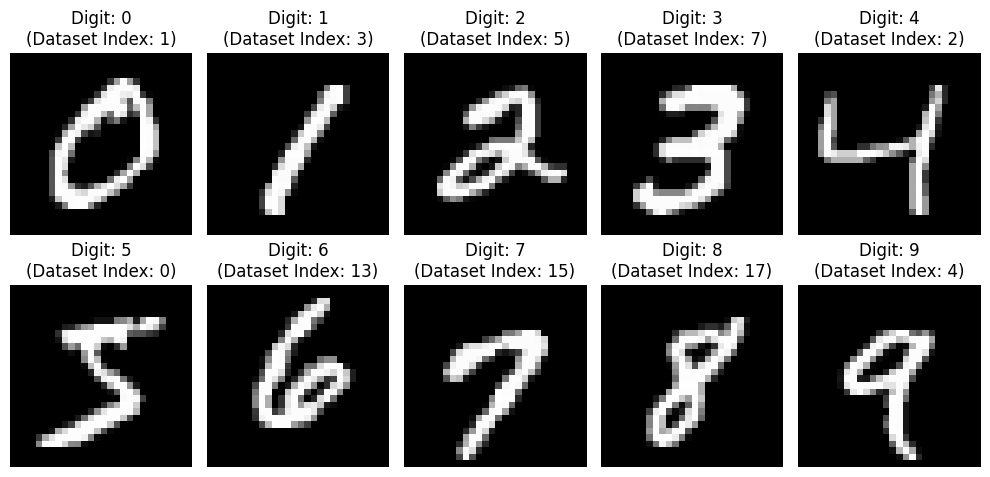

In [ ]:
digit_samples = {}
for idx in range(len(train_dataset)):
    image, label = train_dataset[idx]
    if label not in digit_samples:
        digit_samples[label] = (image, idx)
    if len(digit_samples) == 10:
        break

fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for digit in range(10):
    image, idx = digit_samples[digit]
    ax = axes[digit // 5, digit % 5]
    ax.imshow(image.squeeze(), cmap='gray')
    ax.set_title(f"Digit: {digit}\n(Dataset Index: {idx})")
    ax.axis('off')
plt.tight_layout()
plt.show()

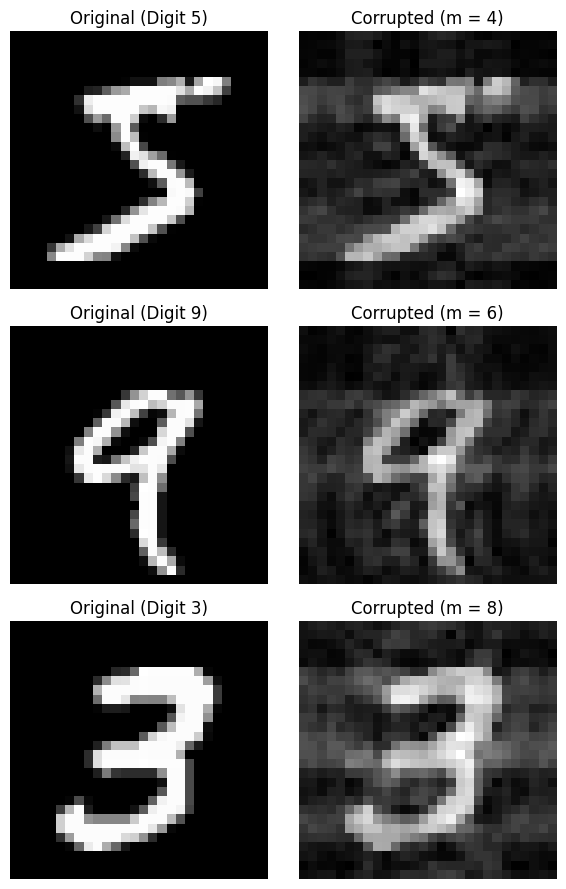

In [ ]:
indices = {
    '5': 0,
    '9': 4,
    '3': 7,
}

m_values = [4, 6, 8]  
digits = ['5', '9', '3']

fig, axes = plt.subplots(3, 2, figsize=(6, 9))

for row, (digit_str, m) in enumerate(zip(digits, m_values)):
    idx = indices[digit_str]
    img_orig = train_dataset[idx][0].squeeze().numpy()
    img_corr = corrupt_fourier(img_orig, m=m)
    
    axes[row, 0].imshow(img_orig, cmap='gray')
    axes[row, 0].set_title(f"Original (Digit {digit_str})")
    axes[row, 0].axis('off')
    
    axes[row, 1].imshow(img_corr, cmap='gray')
    axes[row, 1].set_title(f"Corrupted (m = {m})")
    axes[row, 1].axis('off')

plt.tight_layout()
plt.show()